In [99]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

df = pd.read_csv('flight.csv')

In [100]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [101]:
df.shape

(300153, 12)

In [102]:
df.drop(['Unnamed: 0', 'flight', 'duration'], axis=1, inplace=True)

In [103]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,1,5955


In [104]:
df.shape

(300153, 9)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   source_city       300153 non-null  object
 2   departure_time    300153 non-null  object
 3   stops             300153 non-null  object
 4   arrival_time      300153 non-null  object
 5   destination_city  300153 non-null  object
 6   class             300153 non-null  object
 7   days_left         300153 non-null  int64 
 8   price             300153 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 20.6+ MB


In [106]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

<Axes: xlabel='airline'>

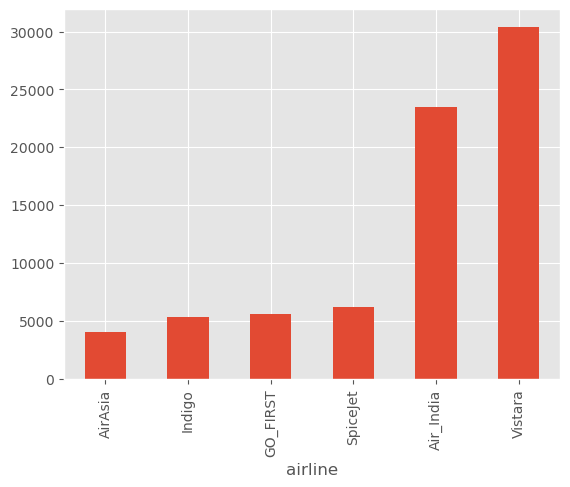

In [107]:
df.groupby('airline')['price'].mean().sort_values().plot(kind='bar')

In [108]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [109]:
df['airline'] = df['airline'].map({'SpiceJet': 0, 'AirAsia': 1, 'Vistara': 2, 'GO_FIRST': 3, 'Indigo': 4, 'Air_India': 5})

In [110]:
df['source_city'] = df['source_city'].map({'Delhi': 0, 'Mumbai': 1, 'Bangalore': 2, 'Kolkata': 3, 'Hyderabad': 4, 'Chennai': 5})

In [111]:
df['destination_city'] = df['destination_city'].map({'Mumbai': 0, 'Bangalore': 1, 'Kolkata': 2, 'Hyderabad': 3, 'Chennai': 4, 'Delhi': 5})

In [112]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [113]:
df['departure_time'] = df['departure_time'].map({'Evening': 0, 'Early_Morning': 1, 'Morning': 2, 'Afternoon': 3, 'Night': 4, 'Late_Night': 5})

In [114]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [115]:
df['arrival_time'] = df['arrival_time'].map({'Night': 0, 'Morning': 1, 'Early_Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Late_Night': 5})

In [116]:
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

In [117]:
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   airline           300153 non-null  int64
 1   source_city       300153 non-null  int64
 2   departure_time    300153 non-null  int64
 3   stops             300153 non-null  int64
 4   arrival_time      300153 non-null  int64
 5   destination_city  300153 non-null  int64
 6   class             300153 non-null  int64
 7   days_left         300153 non-null  int64
 8   price             300153 non-null  int64
dtypes: int64(9)
memory usage: 20.6 MB


In [119]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
days_left           0
price               0
dtype: int64

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [135]:
X = df.drop(['price'], axis=1)
y =df['price']

In [136]:
X.shape

(300153, 8)

In [137]:
y.shape

(300153,)

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [141]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [142]:
model.score(X_train, y_train)

0.9031084987101687

In [143]:
from sklearn.metrics import mean_squared_error, r2_score

In [145]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 49984820.76255543


In [148]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))